# **Prédiction du Comportement des Clients Bancaires - Bank Customer Behavior**

## *__Phase 1__ : Analyse Exploratoire & Preprocessing*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
os.makedirs('data/processed', exist_ok=True)
print("Imports OK")

Imports OK


## 1. Chargement du Dataset

In [3]:
df = pd.read_csv(r'../data/bank-additional/bank-additional-full.csv', sep=';')
print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
df.head()

Shape : (41188, 21)
Colonnes : ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Analyse Exploratoire (EDA)

In [4]:
# Informations générales
print(" Infos générales")
df.info()
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")
print(f"\nDoublons : {df.duplicated().sum()}")

 Infos générales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx 

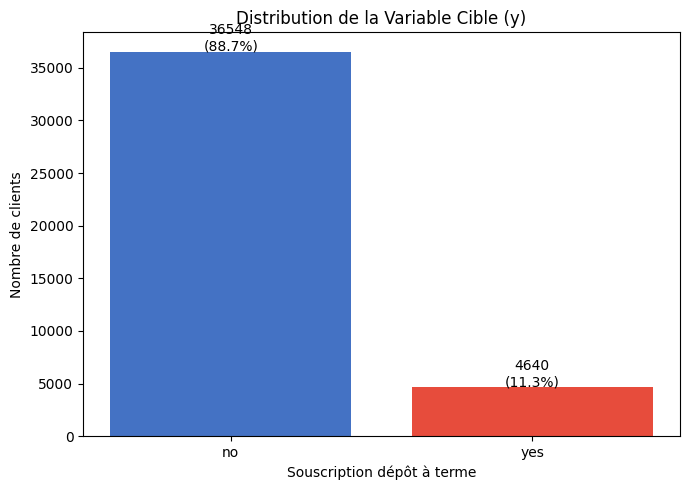

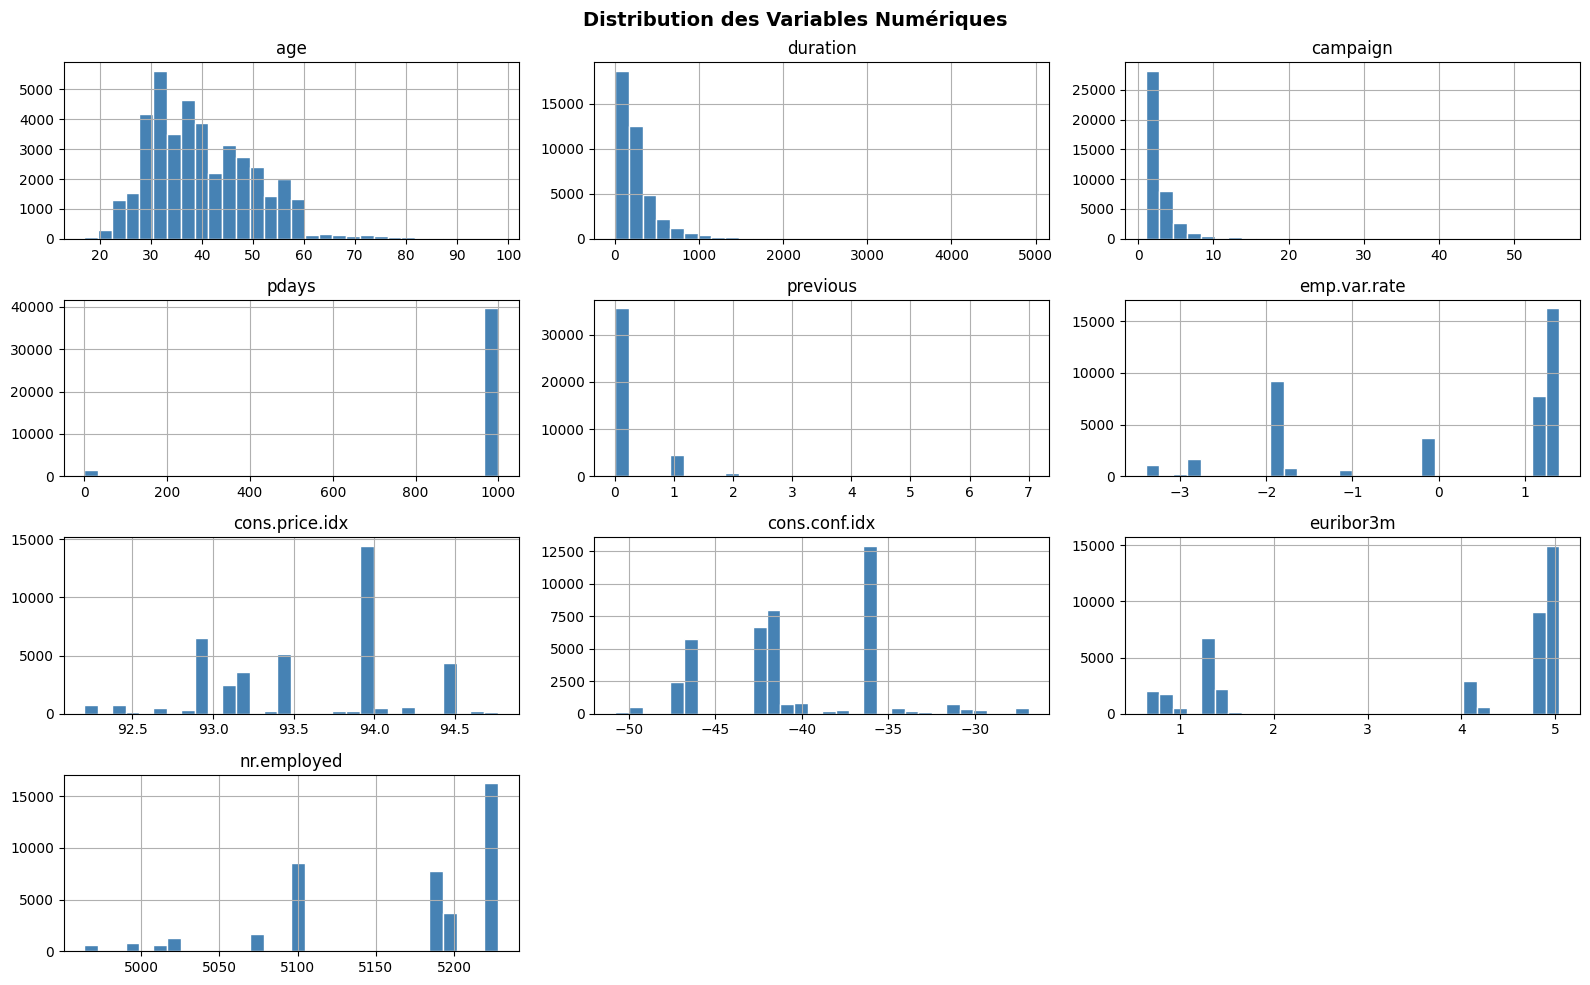

In [5]:
# Distribution de la variable cible
target_counts = df['y'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(target_counts.index, target_counts.values, color=['#4472C4','#E74C3C'])
ax.set_title('Distribution de la Variable Cible (y)')
ax.set_xlabel('Souscription dépôt à terme')
ax.set_ylabel('Nombre de clients')
for i, (idx, val) in enumerate(target_counts.items()):
    ax.text(i, val + 100, f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../results/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Histogrammes variables numériques (graphe séparé)
df.select_dtypes(include=[np.number]).hist(bins=30, figsize=(16, 10),
                                            color='steelblue', edgecolor='white')
plt.suptitle('Distribution des Variables Numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

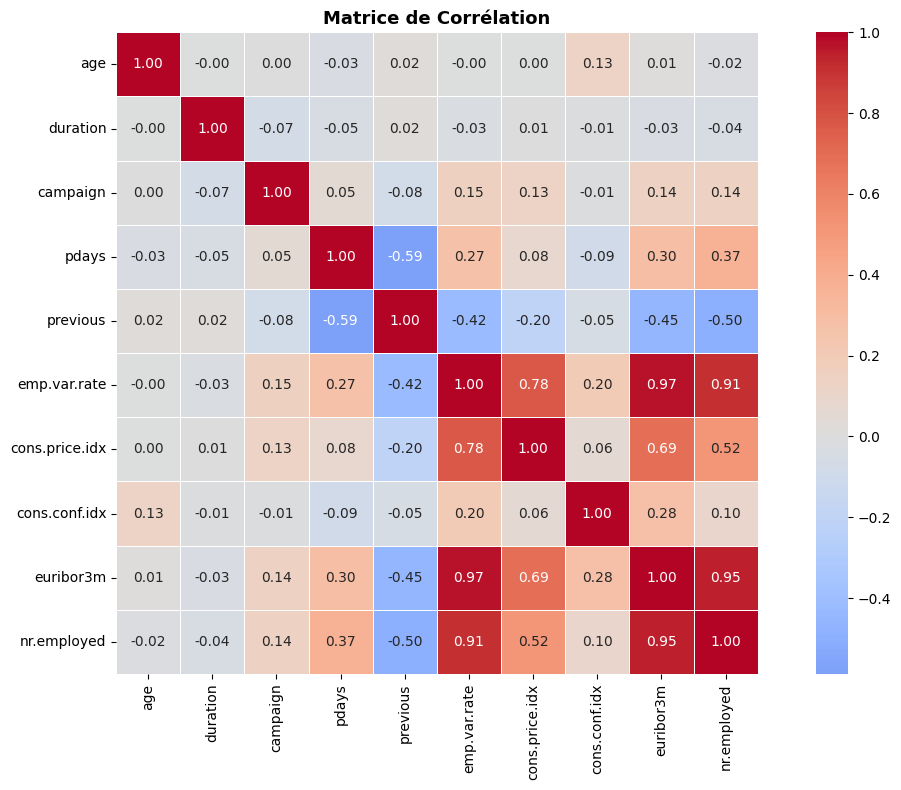

In [6]:
# Corrélations
fig, ax = plt.subplots(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.5)
ax.set_title('Matrice de Corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

Variables catégorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


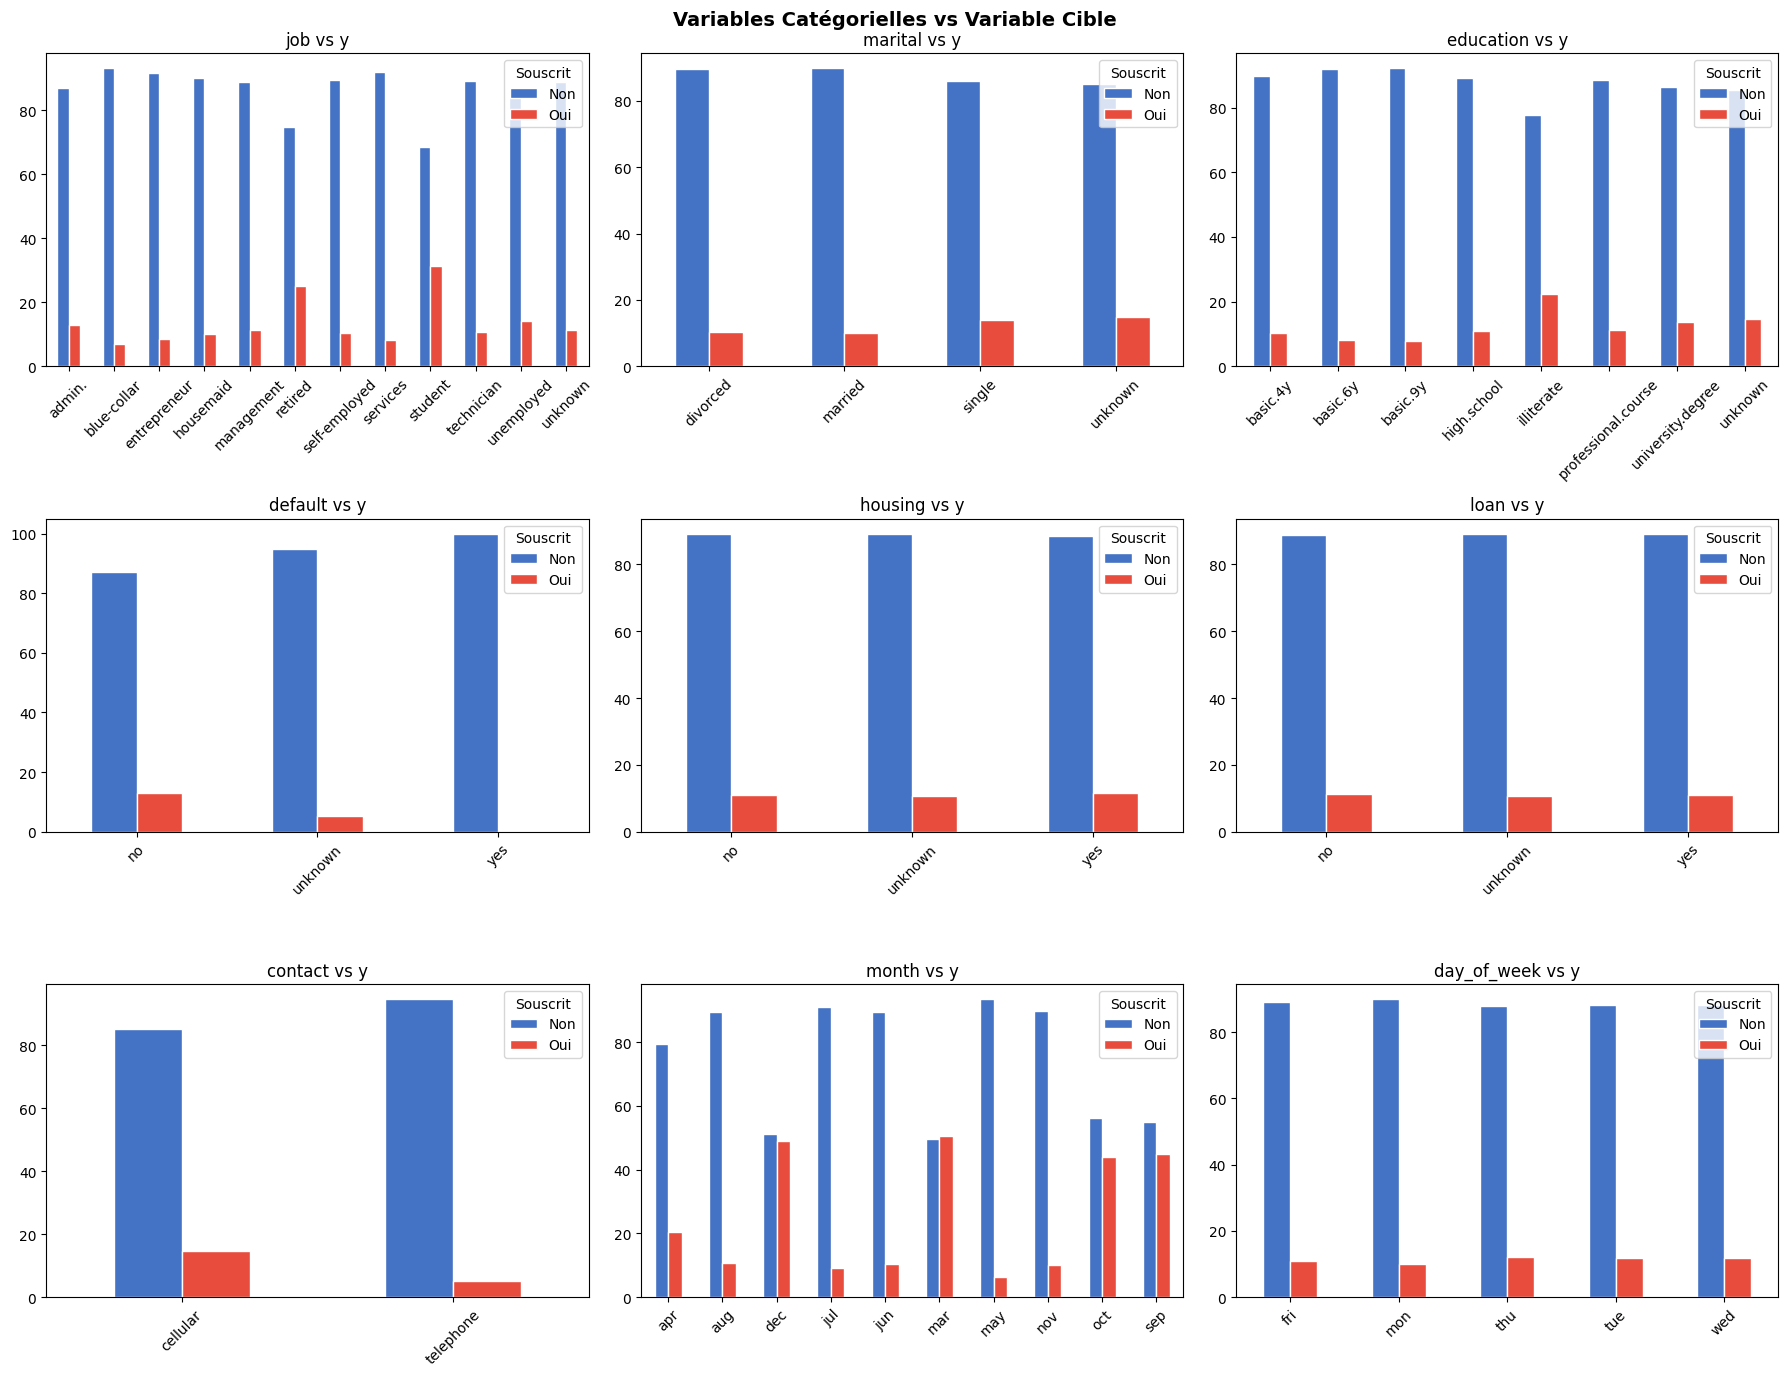

In [7]:
# Variables catégorielles vs cible
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')
print(f"Variables catégorielles : {cat_cols}")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols[:9]):
    ct = pd.crosstab(df[col], df['y'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#4472C4','#E74C3C'], edgecolor='white')
    axes[i].set_title(f'{col} vs y')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(['Non', 'Oui'], title='Souscrit')
plt.suptitle('Variables Catégorielles vs Variable Cible', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/eda_categoricals.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [8]:
df_clean = df.copy()

# Encodage de la cible
df_clean['y'] = (df_clean['y'] == 'yes').astype(int)
print(f"Cible encodée : {df_clean['y'].value_counts().to_dict()}")

# Transformation pdays en binaire (999 = jamais contacté)
df_clean['pdays_contacted'] = (df_clean['pdays'] != 999).astype(int)
df_clean.drop('pdays', axis=1, inplace=True)
print(f"pdays -> pdays_contacted : {df_clean['pdays_contacted'].value_counts().to_dict()}")

# Suppression de duration (non disponible avant l'appel -> inutilisable en production)
df_clean.drop('duration', axis=1, inplace=True)
print("duration supprimée")

# Suppression de day_of_week (non discriminant)
df_clean.drop('day_of_week', axis=1, inplace=True)
print("day_of_week supprimée")

# Remplacement des 'unknown' par le mode
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].replace('unknown', np.nan)
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        print(f"  {col} : valeurs manquantes remplacées par le mode")

# Suppression des doublons
print(f"\nDoublons supprimés : {df_clean.duplicated().sum()}")
df_clean.drop_duplicates(inplace=True)
print(f"Shape après nettoyage : {df_clean.shape}")

Cible encodée : {0: 36548, 1: 4640}
pdays -> pdays_contacted : {0: 39673, 1: 1515}
duration supprimée
day_of_week supprimée
  job : valeurs manquantes remplacées par le mode
  marital : valeurs manquantes remplacées par le mode
  education : valeurs manquantes remplacées par le mode
  default : valeurs manquantes remplacées par le mode
  housing : valeurs manquantes remplacées par le mode
  loan : valeurs manquantes remplacées par le mode

Doublons supprimés : 2767
Shape après nettoyage : (38421, 19)


In [9]:
# One-Hot Encoding des variables catégorielles
cat_cols_encode = df_clean.select_dtypes(include='object').columns.tolist()
print(f"Colonnes à encoder : {cat_cols_encode}")

df_encoded = pd.get_dummies(df_clean, columns=cat_cols_encode, drop_first=True)
print(f"\nShape après encoding : {df_encoded.shape}")

Colonnes à encoder : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Shape après encoding : (38421, 43)


In [10]:
# Séparation features / cible
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

print(f"Features : {X.shape[1]} | Observations : {X.shape[0]}")

# Split train/test (80/20 stratifié)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f"\nTrain : {X_train.shape} | Test : {X_test.shape}")
print(f"Déséquilibre train : {y_train.value_counts().to_dict()}")

Features : 42 | Observations : 38421

Train : (30736, 42) | Test : (7685, 42)
Déséquilibre train : {0: 27067, 1: 3669}


In [11]:
# SMOTE sur le train uniquement
print("Application de SMOTE...")
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Après SMOTE : {pd.Series(y_train_res).value_counts().to_dict()}")

Application de SMOTE...
Après SMOTE : {0: 27067, 1: 27067}


In [12]:
# Sauvegarde des données preprocessées
X_train_res.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
pd.DataFrame(y_train_res, columns=['y']).to_csv('../data/processed/y_train.csv', index=False)
pd.DataFrame(y_test).reset_index(drop=True).to_csv('../data/processed/y_test.csv', index=False)

# Sauvegarde des noms de colonnes
pd.Series(X.columns.tolist()).to_csv('../data/processed/feature_names.csv', index=False)

print("Données sauvegardées dans data/processed/")
print(f" X_train : {X_train_res.shape}")
print(f" X_test : {X_test.shape}")

Données sauvegardées dans data/processed/
 X_train : (54134, 42)
 X_test : (7685, 42)


## *__Phase 2 :__ Classificateurs de Base*

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score,
    average_precision_score, roc_curve
)
import shap

SEED = 42
np.random.seed(SEED)
os.makedirs('models', exist_ok=True)
print("Imports OK")

Imports OK


## 1. Chargement des Données

In [4]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Déséquilibre test : {pd.Series(y_test).value_counts().to_dict()}")

X_train : (54134, 42) | X_test : (7685, 42)
Déséquilibre test : {0: 6768, 1: 917}


## 2. Définition des Modèles

In [5]:
models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Arbre de Décision': DecisionTreeClassifier(max_depth=10, random_state=SEED, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED, class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
}
print(f"{len(models)} modèles définis.")

6 modèles définis.


## 3. Cross-Validation (5-Fold)

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, clf in models.items():
    print(f"  Entraînement : {name}...", end=' ')
    scores = cross_validate(clf, X_train, y_train, cv=cv,
                            scoring=['roc_auc','f1','accuracy'],
                            n_jobs=-1, return_train_score=False)
    cv_results[name] = {
        'AUC-ROC (CV)': scores['test_roc_auc'].mean(),
        'F1 (CV)':      scores['test_f1'].mean(),
        'Accuracy (CV)':scores['test_accuracy'].mean(),
    }
    print(f"AUC={scores['test_roc_auc'].mean():.4f} | F1={scores['test_f1'].mean():.4f}")

df_cv = pd.DataFrame(cv_results).T.sort_values('AUC-ROC (CV)', ascending=False)
print("\nRésultats Cross-Validation :")
display(df_cv.style.highlight_max(color="#088321").format('{:.4f}'))

  Entraînement : Régression Logistique... 

KeyboardInterrupt: 